In [1]:
import pypots
import os

: 

I need to divide the date dependant features and independeant ones

I should use independant for MICE

I should use MCAR to remove some date  (Not from the first task in the )

In [20]:
import pandas as pd
import numpy as np
import logging
from types import SimpleNamespace

# simple logger (to keep your logger.info line working)
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("preprocess")

# mimic argparse args with your two paths
args = SimpleNamespace(
    ground_truth_path=r"C:\Users\vikto\Documents\SAITS\bcer_data\fn_tasks_ground_truth_required_new_data.txt",
    missing_data_path=r"C:\Users\vikto\Documents\SAITS\bcer_data\fn_tasks_missing_required_new_data.txt",
)


In [21]:
# Load datasets
df_ground = pd.read_csv(args.ground_truth_path)
df_missing = pd.read_csv(args.missing_data_path)
# Print number of samples
num_samples_ground = len(df_ground)
logger.info(f"Total samples in ground truth: {num_samples_ground}")

# Print missing value counts
missing_in_ground = df_ground["STARTED_DURATION"].isna().sum()
missing_in_missing = df_missing["STARTED_DURATION"].isna().sum()
print(f"Missing STARTED_DURATION in ground truth: {missing_in_ground}")
print(f"Missing STARTED_DURATION in missing data file: {missing_in_missing}")


INFO:preprocess:Total samples in ground truth: 23445


Missing STARTED_DURATION in ground truth: 5326
Missing STARTED_DURATION in missing data file: 8043


In [22]:
# Merge ground truth and missing data
df_missing['STARTED_DURATION_ground'] = df_ground['STARTED_DURATION']
# Remove MISSING_FLAG column
df_missing.drop(columns=['MISSING_FLAG'], inplace=True, errors='ignore')

df_missing.sort_values(by=['CREATED_DATE_hours'], inplace=True)
df_missing.set_index(['APPLICATION_TASK_ID'], inplace=True)


In [23]:
exclude_features = [
    "APPLICATION_NUMBER","TASK_NAME", "USER_ID", "APPLICATION_TYPE_CODE", "PROPONENT", "SUBMITTED_DATE_hours",
    "ASSIGN_DATE_hours", "ASSIGN_DURATION", "MEDIAN_CREATED_DURATION", "MEDIAN_ASSIGN_DURATION", "APPLICATION_STATUS_CODE",
    "MEDIAN_FIRST_ASSIGN_DURATION", "DETERMINATION_DATE_hours", "FIRST_ASSIGN_hours"
]
df_missing['APPLICATION_STATUS_CODE2'] = df_missing['APPLICATION_STATUS_CODE'].apply(
    lambda x: 1 if x in [0, 2] else 0
)
df_missing.drop(columns=exclude_features, inplace=True, errors='ignore')
df_missing

,REVISION_NUMBER,TASK_ITERATION,USER_TASK_STATUS,CREATED_DURATION,STARTED_DURATION,FIRST_ASSIGN_DURATION,TASK_HISTORY_STATUS_CHANGES,HALT_DURATION,APPLICATION_DURATION,HIGH_RISK_IND,...,OPEN_APPLICATIONS,OPEN_TASKS,PRIORITY_CODE,TOTAL_ACTIVITY_COUNT,WAITING_TIME,TASK_COUNT,CREATED_DATE_hours,LATEST_DATE_hours,STARTED_DURATION_ground,APPLICATION_STATUS_CODE2
APPLICATION_TASK_ID,,,,,,,,,,,,,,,,,,,,,
340242,0,0,0,120.100000,NaN,73.133333,6,0.0,61.470139,0,...,0,0,0,1,1.000000,12,275.666667,395.766667,NaN,1
340243,0,0,0,120.083333,NaN,73.116667,6,0.0,61.470139,0,...,0,0,0,1,1.000000,12,275.666667,395.750000,NaN,1
340244,0,0,0,120.050000,NaN,73.083333,6,0.0,61.470139,0,...,0,0,0,1,1.000000,12,275.666667,395.716667,NaN,1
340245,0,0,0,120.066667,NaN,73.100000,6,0.0,61.470139,0,...,0,0,0,1,1.000000,12,275.666667,395.733333,NaN,1
340246,0,0,0,120.033333,NaN,73.050000,6,0.0,61.470139,0,...,0,0,0,1,1.000000,12,275.666667,395.700000,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12957154,0,0,0,50.866667,22.753056,26.500000,10,0.0,30.197222,0,...,104,14,1,1,24.083183,11,70712.566667,70763.433333,22.753056,1
12957162,0,0,0,529.216667,501.060000,504.866667,12,0.0,30.197222,0,...,104,0,1,1,24.083183,11,70712.583333,71241.800000,501.060000,1
12957170,0,0,0,528.933333,500.743333,504.583333,12,0.0,30.197222,0,...,104,5,1,1,24.083183,11,70712.583333,71241.516667,500.743333,1


In [24]:
binary_columns = ["HIGH_RISK_IND", "MAJOR_PROJECT_IND", "PRIORITY_CODE", "USER_TASK_STATUS", "APPLICATION_STATUS_CODE2"]

no_log_transform_features = [
    "REVISION_NUMBER", "TASK_ITERATION", "TASK_HISTORY_STATUS_CHANGES", "TASK_COUNT",
    "OPEN_APPLICATIONS", "OPEN_TASKS", "TOTAL_ACTIVITY_COUNT", "WAITING_TIME", "APPLICATION_DURATION"
]
df_missing[binary_columns] = df_missing[binary_columns].replace(2, 0)
df_missing[binary_columns] = df_missing[binary_columns].astype(int)


In [25]:
# Define feature columns
feature_columns = [
    col for col in df_missing.columns
    if col not in exclude_features + binary_columns + ['STARTED_DURATION_ground', 'STARTED_DATE_ground']
    and not col.startswith("TASK_NAME")
]

log_transform_features = [
    col for col in feature_columns
    if col not in no_log_transform_features + binary_columns + ['STARTED_DURATION_ground', 'STARTED_DATE_ground']
    and not col.startswith("TASK_NAME")
]
log_transform_features

['CREATED_DURATION',
 'STARTED_DURATION',
 'FIRST_ASSIGN_DURATION',
 'HALT_DURATION',
 'CREATED_DATE_hours',
 'LATEST_DATE_hours']

In [26]:
# Check for negative values in features that will be log-transformed
negative_features = df_missing[log_transform_features].lt(0).any()
negative_columns = negative_features[negative_features].index.tolist()

negative_started_duration_indices = df_missing[df_missing['CREATED_DURATION'] < 0].index.tolist()

print(f"Found {len(negative_started_duration_indices)} rows with negative STARTED_DURATION.")
print(negative_started_duration_indices)


Found 0 rows with negative STARTED_DURATION.
[]


In [27]:
df_missing.loc[df_missing['FIRST_ASSIGN_DURATION'] < 0, 'FIRST_ASSIGN_DURATION'] = df_missing['CREATED_DURATION']
df_missing.loc[df_missing['STARTED_DURATION'] < 0, 'STARTED_DURATION'] = df_missing['FIRST_ASSIGN_DURATION']
df_missing.loc[df_missing['STARTED_DURATION_ground'] < 0, 'STARTED_DURATION_ground'] = df_missing['FIRST_ASSIGN_DURATION']

In [28]:
# === snapshot a fully independent copy BEFORE scaling ===
df_before_scaling = df_missing.copy(deep=True)    


In [29]:
# Apply log1p transformation (log(x+1))
df_missing[log_transform_features] = np.log1p(df_missing[log_transform_features])
df_missing[['STARTED_DURATION_ground']] = np.log1p(df_missing[['STARTED_DURATION_ground']])


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Fit the main scaler on feature columns
scaler = StandardScaler()
df_missing[feature_columns] = scaler.fit_transform(df_missing[feature_columns])

# Identify the correct index of STARTED_DURATION in feature_columns
duration_index = feature_columns.index("STARTED_DURATION")

# Extract mean and std of STARTED_DURATION from the fitted scaler
duration_mean = scaler.mean_[duration_index]
duration_std  = scaler.scale_[duration_index]

# Standardize STARTED_DURATION_ground using the same mean and std
df_missing['STARTED_DURATION_ground'] = (df_missing['STARTED_DURATION_ground'] - duration_mean) / duration_std


In [31]:
# Create stratification bins using CREATED_DATE_hours
df_missing["created_bin"] = pd.qcut(
    df_missing["CREATED_DATE_hours"], q=10, labels=False, duplicates="drop"
)

# Define bins
val_bins = [4, 9]
test_bins = [5]
excluded_bins = val_bins + test_bins

train_bins = [b for b in df_missing["created_bin"].unique() if b not in excluded_bins]

# Split data
train_df = df_missing[df_missing["created_bin"].isin(train_bins)].copy()
val_df   = df_missing[df_missing["created_bin"].isin(val_bins)].copy()
test_df = df_missing[df_missing["created_bin"].isin(test_bins)].copy()


In [ ]:
def prepare_sequences(df: pd.DataFrame, sequence_length: int = 10):
    """
    Generate sequences and corresponding masks for a given preprocessed DataFrame.
    Sequences are built within the same created_bin; every window is full length.
    """
    # Missing-view (X_hat): drop helper cols not used as features
    X_hat = df.drop(columns=['STARTED_DURATION_ground', 'created_bin']).to_numpy()

    # Ground-replaced view (X): copy then overwrite STARTED_DURATION with its ground truth
    df_eval = df.copy()
    df_eval['STARTED_DURATION'] = df_eval['STARTED_DURATION_ground']
    X = df_eval.drop(columns=['STARTED_DURATION_ground', 'created_bin']).to_numpy()

    # Masks
    missing_mask = (~np.isnan(X_hat)).astype(np.float32)
    indicating_mask = ((~np.isnan(X_hat)) ^ (~np.isnan(X))).astype(np.float32) #What is this for?

    # Collectors
    X_seqs, X_hat_seqs = [], []
    missing_mask_seqs, indicating_mask_seqs = [], []
    ids_seqs, timestamps_seqs = [], []

    created_bins = df["created_bin"].values
    idx_vals     = df.index.values
    n = len(df)

    for start in range(0, n - sequence_length + 1):
        end = start + sequence_length
        window_bins = created_bins[start:end]

        # Ensure the entire sequence is from the same bin
        if np.all(window_bins == window_bins[0]):
            X_seqs.append(X[start:end])
            X_hat_seqs.append(X_hat[start:end])
            missing_mask_seqs.append(missing_mask[start:end])
            indicating_mask_seqs.append(indicating_mask[start:end])
            ids_seqs.append(idx_vals[start:end])

    return {
        "X":               np.array(X_seqs),
        "X_hat":           np.array(X_hat_seqs),
        "missing_mask":    np.array(missing_mask_seqs),
        "indicating_mask": np.array(indicating_mask_seqs),
        "original_ids":    np.array(ids_seqs),
    }


In [33]:
train_set_dict = prepare_sequences(train_df, 10)
val_set_dict   = prepare_sequences(val_df,   10)

test_set_dict = prepare_sequences(test_df, 10)

all_data = pd.concat([train_df, val_df, test_df]).sort_values(by="CREATED_DATE_hours")
all_data_dict = prepare_sequences(all_data, 10)

print("train X:", train_set_dict["X"].shape,
      "val X:",   val_set_dict["X"].shape,
      "test X:",  test_set_dict["X"].shape,
      "all_data", all_data_dict["X"].shape)


train X: (16354, 10, 20) val X: (4664, 10, 20) test X: (2337, 10, 20) all_data (23355, 10, 20)


In [34]:
def _f32(a): return a.astype(np.float32)

# --- Training set MUST include X_ori and indicating_mask ---
dataset_for_IMPU_training = {
    "X":               _f32(train_set_dict["X_hat"]),          # missing-view with NaNs
    "X_ori":           _f32(train_set_dict["X"]),              # ground-truth-replaced view
    "missing_mask":    _f32(train_set_dict["missing_mask"]),   # 1=observed in X_hat
    "indicating_mask": _f32(train_set_dict["indicating_mask"]) # 1=imputable (present in X, missing in X_hat)
}

# Validation set (needs X_ori too)
dataset_for_IMPU_validating = {
    "X":               _f32(val_set_dict["X_hat"]),
    "X_ori":           _f32(val_set_dict["X"]),
    "missing_mask":    _f32(val_set_dict["missing_mask"]),
    "indicating_mask": _f32(val_set_dict["indicating_mask"]),
}

# Test set (X only; we’ll compute metrics with mask)
dataset_for_IMPU_testing = {
    "X": _f32(test_set_dict["X_hat"]),
}

# Test helpers
test_X_indicating_mask = np.isnan(test_set_dict["X"]) ^ np.isnan(test_set_dict["X_hat"])
test_X_ori = np.nan_to_num(test_set_dict["X"]).astype(np.float32)

print("TRAIN | imprutable cells:", int(dataset_for_IMPU_training["indicating_mask"].sum()))
print("VAL   | imprutable cells:", int(dataset_for_IMPU_validating["indicating_mask"].sum()))
print("TEST  | imprutable cells:", int(test_X_indicating_mask.sum()))

TRAIN | imprutable cells: 19720
VAL   | imprutable cells: 5342
TEST  | imprutable cells: 2026


In [35]:
# Infer model dimensions from the training set
n_steps    = train_set_dict["X_hat"].shape[1]   # T
n_features = train_set_dict["X_hat"].shape[2]   # D
print(f"n_steps={n_steps}, n_features={n_features}")


n_steps=10, n_features=20


In [36]:
OUTPUT_DIR = r"pypots_outputs" 
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
### Runs around 6 mins ###

# Run SAITS imputation with "unlimited" epochs (very large), stop via early stopping
from pypots.nn.functional import calc_mae
from pypots.optim import Adam
from pypots.imputation import SAITS
from pypots.nn.modules.loss import MAE
import torch


# Use the dimensions we already computed from the training tensors
print(f"n_steps={n_steps}, n_features={n_features}")

MAX_EPOCHS = 10000      # effectively unlimited
PATIENCE   = 30         # stop if val loss doesn't improve for 30 epochs (tune as you like)

saits = SAITS(
    n_steps=int(n_steps),
    n_features=int(n_features),
    n_layers=2,
    d_model=128,
    d_ffn=256,
    n_heads=2,
    d_k=64,
    d_v=64,
    dropout=0,
    ORT_weight=1,
    MIT_weight=1,
    batch_size=128,
    epochs=MAX_EPOCHS,       
    patience=PATIENCE,        # early stopping trigger
    optimizer=Adam(lr=0.004327478052739919),
    num_workers=0,
    device="cuda" if torch.cuda.is_available() else "cpu",  
    saving_path=os.path.join(OUTPUT_DIR, "saits"),
    model_saving_strategy="best",
    validation_metric = MAE
)

# Train with validation for early stopping/model selection
saits.fit(
    train_set=dataset_for_IMPU_training,     # {"X": train_X_hat}
    val_set=dataset_for_IMPU_validating      # {"X": val_X_hat, "X_ori": val_X}
)

# Test-time imputation
pred = saits.predict(test_set=dataset_for_IMPU_testing)  # {"X": test_X_hat}
imputation = pred["imputation"]

# Evaluate only where ground truth exists but the missing view had NaN
mae = calc_mae(imputation, test_X_ori, test_X_indicating_mask)
print(f"Testing mean absolute error: {mae:.6f}")


2025-10-01 11:23:56 [INFO]: Using the given device: cuda
2025-10-01 11:23:56 [INFO]: Model files will be saved to pypots_outputs\saits\20251001_T112356
2025-10-01 11:23:56 [INFO]: Tensorboard file will be saved to pypots_outputs\saits\20251001_T112356\tensorboard
2025-10-01 11:23:56 [INFO]: Using customized MAE as the training loss function.
2025-10-01 11:23:56 [INFO]: Using customized MAE as the validation metric function.
2025-10-01 11:23:56 [INFO]: SAITS initialized with the given hyperparameters, the number of trainable parameters: 544,568


n_steps=10, n_features=20


2025-10-01 11:23:59 [INFO]: Epoch 001 - training loss (MAE): 0.6593, validation MAE: 0.2137
2025-10-01 11:24:02 [INFO]: Epoch 002 - training loss (MAE): 0.4516, validation MAE: 0.1665
2025-10-01 11:24:05 [INFO]: Epoch 003 - training loss (MAE): 0.3840, validation MAE: 0.1808
2025-10-01 11:24:08 [INFO]: Epoch 004 - training loss (MAE): 0.3558, validation MAE: 0.2029
2025-10-01 11:24:11 [INFO]: Epoch 005 - training loss (MAE): 0.3309, validation MAE: 0.1333
2025-10-01 11:24:14 [INFO]: Epoch 006 - training loss (MAE): 0.3187, validation MAE: 0.1423
2025-10-01 11:24:17 [INFO]: Epoch 007 - training loss (MAE): 0.3172, validation MAE: 0.1411
2025-10-01 11:24:20 [INFO]: Epoch 008 - training loss (MAE): 0.3107, validation MAE: 0.1390
2025-10-01 11:24:23 [INFO]: Epoch 009 - training loss (MAE): 0.3041, validation MAE: 0.1325
2025-10-01 11:24:25 [INFO]: Epoch 010 - training loss (MAE): 0.3021, validation MAE: 0.1407
2025-10-01 11:24:28 [INFO]: Epoch 011 - training loss (MAE): 0.2943, validation 

Testing mean absolute error: 0.123758


In [38]:
target_feature = "STARTED_DURATION"  
target_idx = feature_columns.index(target_feature)

# Keep only positions flagged by the indicator mask
m = test_X_indicating_mask.astype(bool)   # shape (N, T, D)

y_true = test_X_ori[m]      # ground truth values at those positions
y_pred = imputation[m]      # model’s imputed values at those positions

# ---- inverse STANDARDIZATION for the target feature (IMPORTANT - only target feature is missing, change code logic if more features are masked)----
mu = float(scaler.mean_[target_idx])
sd = float(scaler.scale_[target_idx])
y_true_lin = y_true * sd + mu
y_pred_lin = y_pred * sd + mu

y_true_lin = np.expm1(y_true_lin)
y_pred_lin = np.expm1(y_pred_lin)


In [39]:
i, t, _ = np.where(m)  # (N_idx, T_idx, D_idx); D_idx is the target column in your case
task_ids = test_set_dict["original_ids"][i, t]

# build table and average overlapping windows per task
df = pd.DataFrame({
    "APPLICATION_TASK_ID": task_ids,
    "gt_original_units":   y_true_lin.astype(float),
    "pred_original_units": y_pred_lin.astype(float),
})
agg = df.groupby("APPLICATION_TASK_ID", as_index=False).mean(numeric_only=True)

# MAE after aggregation
mae_orig = float(np.mean(np.abs(agg["pred_original_units"] - agg["gt_original_units"])))
print(f"[{target_feature}] MAE (aggregated by TASK_ID, original units): {mae_orig:.6f}")
print("Unique tasks evaluated:", len(agg))



[STARTED_DURATION] MAE (aggregated by TASK_ID, original units): 67.458190
Unique tasks evaluated: 204


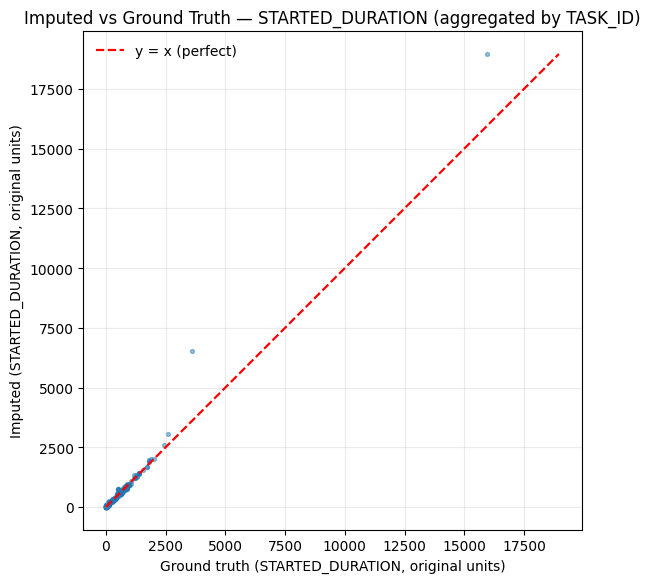

In [40]:
# ---- scatter of AGGREGATED (by TASK_ID) predictions vs ground truth in original units ----
import matplotlib.pyplot as plt

x = agg["gt_original_units"].to_numpy()
y = agg["pred_original_units"].to_numpy()

plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=8, alpha=0.45, color="tab:blue")

lo = float(min(x.min(), y.min()))
hi = float(max(x.max(), y.max()))
plt.plot([lo, hi], [lo, hi], linestyle="--", color="red", linewidth=1.6, label="y = x (perfect)")

plt.xlabel(f"Ground truth ({target_feature}, original units)")
plt.ylabel(f"Imputed ({target_feature}, original units)")
plt.title(f"Imputed vs Ground Truth — {target_feature} (aggregated by TASK_ID)")
plt.gca().set_aspect("equal", "box")
plt.grid(True, alpha=0.25)
plt.legend(frameon=False, loc="best")
plt.tight_layout()
plt.show()


In [41]:
x = agg["gt_original_units"].to_numpy(dtype=float)     # ground truth
y = agg["pred_original_units"].to_numpy(dtype=float)   # predictions
err = y - x

MAE  = float(np.mean(np.abs(err)))
RMSE = float(np.sqrt(np.mean(err**2)))
MedE = float(np.median(np.abs(err)))
SS_res = float(np.sum(err**2))
SS_tot = float(np.sum((x - np.mean(x))**2))
R2   = float(1.0 - SS_res / SS_tot) if SS_tot > 0 else float("nan")

print(f"[{target_feature}] metrics on aggregated entries (by TASK_ID):")
print(f"  MAE : {MAE:.6f}")
print(f"  RMSE: {RMSE:.6f}")
print(f"  MedE: {MedE:.6f}")
print(f"  R^2 : {R2:.6f}")


[STARTED_DURATION] metrics on aggregated entries (by TASK_ID):
  MAE : 67.458190
  RMSE: 302.324466
  MedE: 22.118762
  R^2 : 0.937404


In [42]:
# Use X (ground-truth view) so SAITS sees more observed context.
dataset_for_IMPU_all_ctx = {"X": all_data_dict["X"].astype(np.float32)}
pred_all_ctx = saits.predict(dataset_for_IMPU_all_ctx)
imputation_all_ctx = pred_all_ctx["imputation"]  # shape: (N_all, T, D)
print("imputation_all_ctx:", imputation_all_ctx.shape)

imputation_all_ctx: (23355, 10, 20)


In [43]:
m   = (all_data_dict["missing_mask"]  == 0) & (all_data_dict["indicating_mask"] == 0)    # (N,T,D) -> originally missing

y_pred = imputation_all_ctx[m]      # model’s imputed values at those positions
created_duration = all_data_dict["X"][m]
# ---- inverse STANDARDIZATION only for the target feature ----
mu = float(scaler.mean_[target_idx])
sd = float(scaler.scale_[target_idx])
y_pred_lin = y_pred * sd + mu

y_pred_lin = np.expm1(y_pred_lin)


created_idx = feature_columns.index("CREATED_DURATION")

mu_created = float(scaler.mean_[created_idx])
sd = float(scaler.scale_[created_idx])
created_duration_lin = created_duration * sd + mu

created_duration_lin = np.expm1(created_duration_lin)


In [44]:
target_feature = "STARTED_DURATION"
target_idx = feature_columns.index(target_feature)

created_feature = "CREATED_DURATION"
created_idx     = feature_columns.index(created_feature)

# 1) mask: missing in X_hat AND not artificially-masked, for the target only
m_t = (all_data_dict["missing_mask"][..., target_idx+1] == 0) & \
      (all_data_dict["indicating_mask"][..., target_idx+1] == 0)   # shape (N, T)

# 2) grab imputed target values at those positions (scaled/log space)
y_pred_s = imputation_all_ctx[..., target_idx+1][m_t].astype(float)

# 3) grab CREATED_DURATION at the same positions (scaled/log space)
created_s = all_data_dict["X"][..., created_idx+1][m_t].astype(float)

# 4) inverse STANDARDIZATION for TARGET
mu_t = float(scaler.mean_[target_idx])
sd_t = float(scaler.scale_[target_idx])
y_pred_lin = y_pred_s * sd_t + mu_t
# undo log1p for target if it was log-transformed
y_pred_lin = np.expm1(y_pred_lin)

# 5) inverse STANDARDIZATION for CREATED_DURATION
mu_c = float(scaler.mean_[created_idx])
sd_c = float(scaler.scale_[created_idx])
created_duration_lin = created_s * sd_c + mu_c
# undo log1p for created_duration if it was log-transformed
created_duration_lin = np.expm1(created_duration_lin)

print("Points (originally-missing target):", y_pred_lin.size)


Points (originally-missing target): 53032


In [48]:
i, t, _ = np.where(m)  # (N_idx, T_idx, D_idx); D_idx is the target column
task_ids = all_data_dict["original_ids"][i, t]

# build table and average overlapping windows per task
df = pd.DataFrame({
    "APPLICATION_TASK_ID": task_ids,
    "pred_original_units": y_pred_lin.astype(float),
    "created_duration": created_duration_lin.astype(float)
})
agg = df.groupby("APPLICATION_TASK_ID", as_index=False).mean(numeric_only=True)


# save CSV next to outputs
if 'OUTPUT_DIR' in globals():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    out_csv = os.path.join(OUTPUT_DIR, f"saits_imp_fn_{target_feature}.csv")
    agg.to_csv(out_csv, index=False)
    print("Saved:", out_csv)


Saved: pypots_outputs\saits_imp_fn_STARTED_DURATION.csv


count    5326.000000
mean       50.514424
std       296.980480
min         0.014988
10%         0.911494
25%         1.127997
50%         1.665578
75%        16.503690
90%        64.954355
max      3697.268447


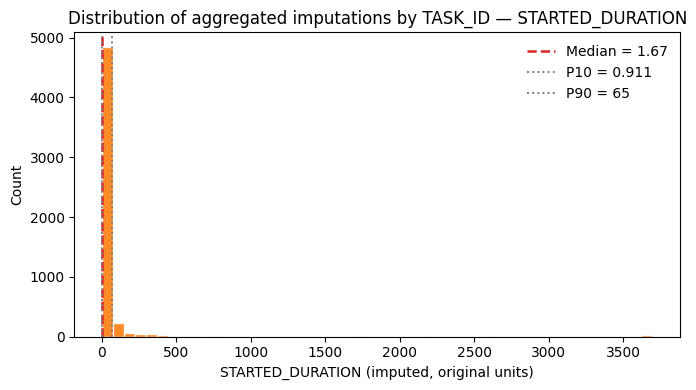

In [46]:
# ---- distribution of aggregated imputations (by TASK_ID), original units ----

vals = agg["pred_original_units"].to_numpy(dtype=float)

# quick stats
stats = pd.Series(vals).describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
print(stats.to_string())

plt.figure(figsize=(7,4))
plt.hist(vals, bins=50, color="tab:orange", alpha=0.9, edgecolor="white")
med = float(np.median(vals))
p10, p90 = np.percentile(vals, [10, 90])

plt.axvline(med, color="tab:red",   linestyle="--", linewidth=1.8, label=f"Median = {med:.3g}")
plt.axvline(p10, color="tab:gray",  linestyle=":",  linewidth=1.4, label=f"P10 = {p10:.3g}")
plt.axvline(p90, color="tab:gray",  linestyle=":",  linewidth=1.4, label=f"P90 = {p90:.3g}")

plt.xlabel(f"{target_feature} (imputed, original units)")
plt.ylabel("Count")
plt.title(f"Distribution of aggregated imputations by TASK_ID — {target_feature}")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [47]:

total_all = len(agg)

in_range = (agg["pred_original_units"] > 0) & (agg["pred_original_units"] < agg["created_duration"])
in_range_valid = in_range.sum()

pct = (in_range_valid / total_all * 100.0) if total_all > 0 else float("nan")

print(f"Total aggregated imputations (all rows): {total_all}")
print(f"In range (0, created_duration): {in_range_valid} / {total_all}  ({pct:.2f}%)")

Total aggregated imputations (all rows): 5326
In range (0, created_duration): 5318 / 5326  (99.85%)


In [ ]:
### Runs around 20 mins ###

from pypots.optim import Adam
from pypots.imputation import BRITS
from pypots.nn.modules.loss import MAE

# initialize the model
brits = BRITS(
    n_steps=n_steps,
    n_features=n_features,
    rnn_hidden_size=512,
    batch_size=128,
    epochs=10000,
    patience=30,
    # give the optimizer.
    optimizer=Adam(lr=0.0010308145099429532),
    # Leaving it to default as 0 means data loading will be in the main process, i.e. there won't be subprocesses.
    num_workers=0,
    # just leave it to default as None, PyPOTS will automatically assign the best device for you.
    device=None,
    # set the path for saving tensorboard and trained model files
    saving_path=os.path.join(OUTPUT_DIR, "brits"),
    # only save the best model after training finished.
    model_saving_strategy="best",
    validation_metric = MAE

)

# train the model on the training set, and validate it on the validating set to select the best model for testing in the next step
brits.fit(
    train_set = dataset_for_IMPU_training,
    val_set = dataset_for_IMPU_validating,
)

# Test-time imputation
brits_pred = brits.predict(test_set=dataset_for_IMPU_testing)  # {"X": test_X_hat}
brits_imputation = brits_pred["imputation"]

# Evaluate only where ground truth exists but the missing view had NaN
mae = calc_mae(imputation, test_X_ori, test_X_indicating_mask)
print(f"Testing mean absolute error: {mae:.6f}")

2025-10-01 11:35:30 [INFO]: No given device, using default device: cuda
2025-10-01 11:35:30 [INFO]: Model files will be saved to pypots_outputs\brits\20251001_T113530
2025-10-01 11:35:30 [INFO]: Tensorboard file will be saved to pypots_outputs\brits\20251001_T113530\tensorboard
2025-10-01 11:35:30 [INFO]: Using customized MAE as the training loss function.
2025-10-01 11:35:30 [INFO]: Using customized MAE as the validation metric function.
2025-10-01 11:35:30 [INFO]: BRITS initialized with the given hyperparameters, the number of trainable parameters: 2,314,528
2025-10-01 11:35:53 [INFO]: Epoch 001 - training loss (MAE): 0.8801, validation MAE: 0.4793
2025-10-01 11:36:07 [INFO]: Epoch 002 - training loss (MAE): 0.6151, validation MAE: 0.3938
2025-10-01 11:36:22 [INFO]: Epoch 003 - training loss (MAE): 0.5418, validation MAE: 0.2826
2025-10-01 11:36:36 [INFO]: Epoch 004 - training loss (MAE): 0.5107, validation MAE: 0.2141
2025-10-01 11:36:51 [INFO]: Epoch 005 - training loss (MAE): 0.49

Testing mean absolute error: 0.123758


In [51]:
target_feature = "STARTED_DURATION" 
target_idx = feature_columns.index(target_feature)

# Keep only positions flagged by the indicator mask
m = test_X_indicating_mask.astype(bool)   # shape (N, T, D)

y_true = test_X_ori[m]      # ground truth values at those positions
y_pred = brits_imputation[m]      # model’s imputed values at those positions

# ---- inverse STANDARDIZATION for the target feature (IMPORTANT - only target feature is missing, change code logic if more features are masked)----
mu = float(scaler.mean_[target_idx])
sd = float(scaler.scale_[target_idx])
y_true_lin = y_true * sd + mu
y_pred_lin = y_pred * sd + mu

y_true_lin = np.expm1(y_true_lin)
y_pred_lin = np.expm1(y_pred_lin)


In [52]:
i, t, _ = np.where(m)  # (N_idx, T_idx, D_idx); D_idx is the target column
task_ids = test_set_dict["original_ids"][i, t]

df = pd.DataFrame({
    "APPLICATION_TASK_ID": task_ids,
    "gt_original_units":   y_true_lin.astype(float),
    "pred_original_units": y_pred_lin.astype(float),
})
agg = df.groupby("APPLICATION_TASK_ID", as_index=False).mean(numeric_only=True)

mae_orig = float(np.mean(np.abs(agg["pred_original_units"] - agg["gt_original_units"])))
print(f"[{target_feature}] MAE (aggregated by TASK_ID, original units): {mae_orig:.6f}")
print("Unique tasks evaluated:", len(agg))



[STARTED_DURATION] MAE (aggregated by TASK_ID, original units): 40.778696
Unique tasks evaluated: 204


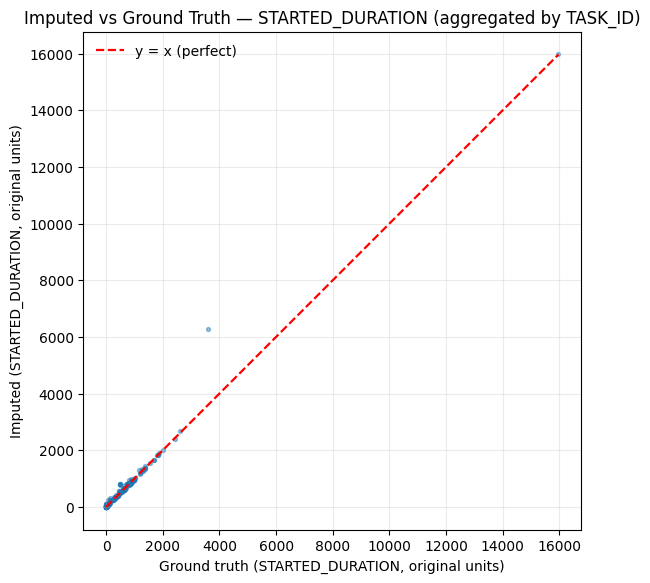

In [53]:
x = agg["gt_original_units"].to_numpy()
y = agg["pred_original_units"].to_numpy()

plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=8, alpha=0.45, color="tab:blue")

lo = float(min(x.min(), y.min()))
hi = float(max(x.max(), y.max()))
plt.plot([lo, hi], [lo, hi], linestyle="--", color="red", linewidth=1.6, label="y = x (perfect)")

plt.xlabel(f"Ground truth ({target_feature}, original units)")
plt.ylabel(f"Imputed ({target_feature}, original units)")
plt.title(f"Imputed vs Ground Truth — {target_feature} (aggregated by TASK_ID)")
plt.gca().set_aspect("equal", "box")
plt.grid(True, alpha=0.25)
plt.legend(frameon=False, loc="best")
plt.tight_layout()
plt.show()


In [54]:
x = agg["gt_original_units"].to_numpy(dtype=float)     # ground truth
y = agg["pred_original_units"].to_numpy(dtype=float)   # predictions
err = y - x

MAE  = float(np.mean(np.abs(err)))
RMSE = float(np.sqrt(np.mean(err**2)))
MedE = float(np.median(np.abs(err)))
SS_res = float(np.sum(err**2))
SS_tot = float(np.sum((x - np.mean(x))**2))
R2   = float(1.0 - SS_res / SS_tot) if SS_tot > 0 else float("nan")

print(f"[{target_feature}] metrics on aggregated entries (by TASK_ID):")
print(f"  MAE : {MAE:.6f}")
print(f"  RMSE: {RMSE:.6f}")
print(f"  MedE: {MedE:.6f}")
print(f"  R^2 : {R2:.6f}")


[STARTED_DURATION] metrics on aggregated entries (by TASK_ID):
  MAE : 40.778696
  RMSE: 196.680640
  MedE: 12.314168
  R^2 : 0.973508


In [55]:
pred_all_ctx = brits.predict(dataset_for_IMPU_all_ctx)
imputation_all_ctx = pred_all_ctx["imputation"]  # shape: (N_all, T, D)
print("imputation_all_ctx:", imputation_all_ctx.shape)

imputation_all_ctx: (23355, 10, 20)


In [56]:
m   = (all_data_dict["missing_mask"]  == 0) & (all_data_dict["indicating_mask"] == 0)    # (N,T,D) -> originally missing

y_pred = imputation_all_ctx[m]      # model’s imputed values at those positions
created_duration = all_data_dict["X"][m]
# ---- inverse STANDARDIZATION only for the target feature ----
mu = float(scaler.mean_[target_idx])
sd = float(scaler.scale_[target_idx])
y_pred_lin = y_pred * sd + mu

y_pred_lin = np.expm1(y_pred_lin)


created_idx = feature_columns.index("CREATED_DURATION")

mu_created = float(scaler.mean_[created_idx])
sd = float(scaler.scale_[created_idx])
created_duration_lin = created_duration * sd + mu

created_duration_lin = np.expm1(created_duration_lin)


In [57]:
target_feature = "STARTED_DURATION"
target_idx = feature_columns.index(target_feature)

created_feature = "CREATED_DURATION"
created_idx     = feature_columns.index(created_feature)

# 1) mask: missing in X_hat AND not artificially-masked, for the target only
m_t = (all_data_dict["missing_mask"][..., target_idx+1] == 0) & \
      (all_data_dict["indicating_mask"][..., target_idx+1] == 0)   # shape (N, T)

# 2) grab imputed target values at those positions (scaled/log space)
y_pred_s = imputation_all_ctx[..., target_idx+1][m_t].astype(float)

# 3) grab CREATED_DURATION at the same positions (scaled/log space)
created_s = all_data_dict["X"][..., created_idx+1][m_t].astype(float)

# 4) inverse STANDARDIZATION for TARGET
mu_t = float(scaler.mean_[target_idx])
sd_t = float(scaler.scale_[target_idx])
y_pred_lin = y_pred_s * sd_t + mu_t
# undo log1p for target if it was log-transformed
y_pred_lin = np.expm1(y_pred_lin)

# 5) inverse STANDARDIZATION for CREATED_DURATION
mu_c = float(scaler.mean_[created_idx])
sd_c = float(scaler.scale_[created_idx])
created_duration_lin = created_s * sd_c + mu_c
# undo log1p for created_duration if it was log-transformed
created_duration_lin = np.expm1(created_duration_lin)

print("Points (originally-missing target):", y_pred_lin.size)


Points (originally-missing target): 53032


In [58]:
i, t, _ = np.where(m)  # (N_idx, T_idx, D_idx); D_idx is the target column 
task_ids = all_data_dict["original_ids"][i, t]

# build table and average overlapping windows per task
df = pd.DataFrame({
    "APPLICATION_TASK_ID": task_ids,
    "pred_original_units": y_pred_lin.astype(float),
    "created_duration": created_duration_lin.astype(float)
})
agg = df.groupby("APPLICATION_TASK_ID", as_index=False).mean(numeric_only=True)


# save CSV next to outputs
if 'OUTPUT_DIR' in globals():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    out_csv = os.path.join(OUTPUT_DIR, f"brits_imp_fn_{target_feature}.csv")
    agg.to_csv(out_csv, index=False)
    print("Saved:", out_csv)


Saved: pypots_outputs\brits_imp_fn_STARTED_DURATION.csv


count    5326.000000
mean       53.947363
std       279.983824
min        -0.026313
10%         0.504083
25%         0.886095
50%         2.031227
75%        20.016937
90%        88.493695
max      3371.521356


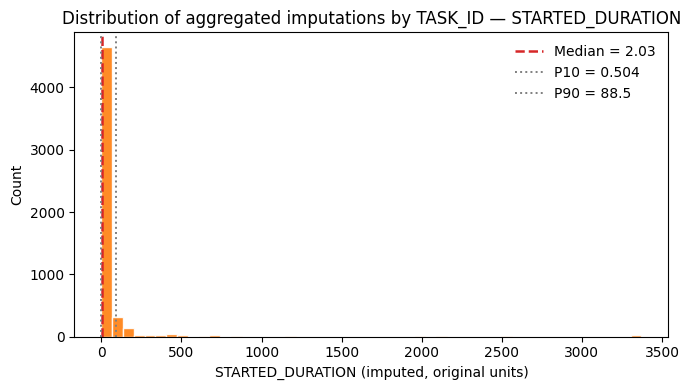

In [59]:
# ---- distribution of aggregated imputations (by TASK_ID), original units ----

vals = agg["pred_original_units"].to_numpy(dtype=float)

# quick stats
stats = pd.Series(vals).describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
print(stats.to_string())

plt.figure(figsize=(7,4))
plt.hist(vals, bins=50, color="tab:orange", alpha=0.9, edgecolor="white")
med = float(np.median(vals))
p10, p90 = np.percentile(vals, [10, 90])

plt.axvline(med, color="tab:red",   linestyle="--", linewidth=1.8, label=f"Median = {med:.3g}")
plt.axvline(p10, color="tab:gray",  linestyle=":",  linewidth=1.4, label=f"P10 = {p10:.3g}")
plt.axvline(p90, color="tab:gray",  linestyle=":",  linewidth=1.4, label=f"P90 = {p90:.3g}")

plt.xlabel(f"{target_feature} (imputed, original units)")
plt.ylabel("Count")
plt.title(f"Distribution of aggregated imputations by TASK_ID — {target_feature}")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [60]:
total_all = len(agg)

in_range = (agg["pred_original_units"] > 0) & (agg["pred_original_units"] < agg["created_duration"])
in_range_valid = in_range.sum()

pct = (in_range_valid / total_all * 100.0) if total_all > 0 else float("nan")

print(f"Total aggregated imputations (all rows): {total_all}")
print(f"In range (0, created_duration): {in_range_valid} / {total_all}  ({pct:.2f}%)")

Total aggregated imputations (all rows): 5326
In range (0, created_duration): 5320 / 5326  (99.89%)


In [113]:
N_DATASETS   = 5    # number of MICE completed datasets
N_ITER       = 30     # MICE iterations
RANDOM_SEED  = 0

# === imports ===
import os, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import miceforest as mf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
os.makedirs(OUTPUT_DIR, exist_ok=True)
np.set_printoptions(suppress=True)

In [114]:
# Drop helper GT column before imputation
to_impute = (
    df_before_scaling
    .drop(columns=["STARTED_DURATION_ground", "APPLICATION_STATUS_CODE2", "USER_TASK_STATUS"], errors="ignore")
    .reset_index(drop=True)  
    .copy()
)
to_impute

,REVISION_NUMBER,TASK_ITERATION,CREATED_DURATION,STARTED_DURATION,FIRST_ASSIGN_DURATION,TASK_HISTORY_STATUS_CHANGES,HALT_DURATION,APPLICATION_DURATION,HIGH_RISK_IND,MAJOR_PROJECT_IND,OPEN_APPLICATIONS,OPEN_TASKS,PRIORITY_CODE,TOTAL_ACTIVITY_COUNT,WAITING_TIME,TASK_COUNT,CREATED_DATE_hours,LATEST_DATE_hours
0,0,0,120.100000,NaN,73.133333,6,0.0,61.470139,0,0,0,0,0,1,1.000000,12,275.666667,395.766667
1,0,0,120.083333,NaN,73.116667,6,0.0,61.470139,0,0,0,0,0,1,1.000000,12,275.666667,395.750000
2,0,0,120.050000,NaN,73.083333,6,0.0,61.470139,0,0,0,0,0,1,1.000000,12,275.666667,395.716667
3,0,0,120.066667,NaN,73.100000,6,0.0,61.470139,0,0,0,0,0,1,1.000000,12,275.666667,395.733333
4,0,0,120.033333,NaN,73.050000,6,0.0,61.470139,0,0,0,0,0,1,1.000000,12,275.666667,395.700000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23440,0,0,50.866667,22.753056,26.500000,10,0.0,30.197222,0,0,104,14,1,1,24.083183,11,70712.566667,70763.433333
23441,0,0,529.216667,501.060000,504.866667,12,0.0,30.197222,0,0,104,0,1,1,24.083183,11,70712.583333,71241.800000
23442,0,0,528.933333,500.743333,504.583333,12,0.0,30.197222,0,0,104,5,1,1,24.083183,11,70712.583333,71241.516667
23443,0,0,530.850000,502.645833,506.516667,12,0.0,30.197222,0,0,104,2,1,1,24.083183,11,70712.600000,71243.450000


In [115]:

# Build and run the kernel
kernel = mf.ImputationKernel(
    to_impute,
    num_datasets=N_DATASETS,
    random_state=RANDOM_SEED,
)
kernel.mice(N_ITER, verbose=True)

# Take the mean across completed datasets for stability
completed = [kernel.complete_data(i) for i in range(N_DATASETS)]
imputed_data = pd.concat(completed).groupby(level=0).mean(numeric_only=True)

print("Imputed dataframe shape:", imputed_data.shape)
imputed_data.head()


Initialized logger with name MICE Iterations 1 - 30 and 4 levels
1 Dataset 0
 | STARTED_DURATION
Dataset 1
 | STARTED_DURATION
Dataset 2
 | STARTED_DURATION
Dataset 3
 | STARTED_DURATION
Dataset 4
 | STARTED_DURATION
2 Dataset 0
 | STARTED_DURATION
Dataset 1
 | STARTED_DURATION
Dataset 2
 | STARTED_DURATION
Dataset 3
 | STARTED_DURATION
Dataset 4
 | STARTED_DURATION
3 Dataset 0
 | STARTED_DURATION
Dataset 1
 | STARTED_DURATION
Dataset 2
 | STARTED_DURATION
Dataset 3
 | STARTED_DURATION
Dataset 4
 | STARTED_DURATION
4 Dataset 0
 | STARTED_DURATION
Dataset 1
 | STARTED_DURATION
Dataset 2
 | STARTED_DURATION
Dataset 3
 | STARTED_DURATION
Dataset 4
 | STARTED_DURATION
5 Dataset 0
 | STARTED_DURATION
Dataset 1
 | STARTED_DURATION
Dataset 2
 | STARTED_DURATION
Dataset 3
 | STARTED_DURATION
Dataset 4
 | STARTED_DURATION
6 Dataset 0
 | STARTED_DURATION
Dataset 1
 | STARTED_DURATION
Dataset 2
 | STARTED_DURATION
Dataset 3
 | STARTED_DURATION
Dataset 4
 | STARTED_DURATION
7 Dataset 0
 | STARTED_

,REVISION_NUMBER,TASK_ITERATION,CREATED_DURATION,STARTED_DURATION,FIRST_ASSIGN_DURATION,TASK_HISTORY_STATUS_CHANGES,HALT_DURATION,APPLICATION_DURATION,HIGH_RISK_IND,MAJOR_PROJECT_IND,OPEN_APPLICATIONS,OPEN_TASKS,PRIORITY_CODE,TOTAL_ACTIVITY_COUNT,WAITING_TIME,TASK_COUNT,CREATED_DATE_hours,LATEST_DATE_hours
0,0.0,0.0,120.100000,46.152722,73.133333,6.0,0.0,61.470139,0.0,0.0,0.0,0.0,0.0,1.0,1.0,12.0,275.666667,395.766667
1,0.0,0.0,120.083333,38.295778,73.116667,6.0,0.0,61.470139,0.0,0.0,0.0,0.0,0.0,1.0,1.0,12.0,275.666667,395.750000
2,0.0,0.0,120.050000,49.945889,73.083333,6.0,0.0,61.470139,0.0,0.0,0.0,0.0,0.0,1.0,1.0,12.0,275.666667,395.716667
3,0.0,0.0,120.066667,55.003444,73.100000,6.0,0.0,61.470139,0.0,0.0,0.0,0.0,0.0,1.0,1.0,12.0,275.666667,395.733333
4,0.0,0.0,120.033333,45.632167,73.050000,6.0,0.0,61.470139,0.0,0.0,0.0,0.0,0.0,1.0,1.0,12.0,275.666667,395.700000


In [116]:
df_eval = df_before_scaling.reset_index(drop=False)  

# artificially-masked rows: missing in `STARTED_DURATION` but GT exists
art_mask_np = (
    df_eval["STARTED_DURATION"].isna().to_numpy() &
    df_eval["STARTED_DURATION_ground"].notna().to_numpy()
)

In [117]:
# pull arrays positionally
imp = imputed_data["STARTED_DURATION"].to_numpy()[art_mask_np]
gt  = df_eval["STARTED_DURATION_ground"].to_numpy()[art_mask_np]

# Metrics
MAE  = float(mean_absolute_error(gt, imp))
RMSE = float(np.sqrt(mean_squared_error(gt, imp)))
MdAE = float(np.median(np.abs(imp - gt)))

R2   = float(r2_score(gt, imp)) if np.var(gt) > 0 else float("nan")

print("=== MICE metrics (artificially-masked) ===")
print(f"MAE : {MAE:.6f}")
print(f"RMSE: {RMSE:.6f}")
print(f"MdAE: {MdAE:.6f}")
print(f"R^2 : {R2:.6f}")

=== MICE metrics (artificially-masked) ===
MAE : 68.186841
RMSE: 229.648843
MdAE: 18.598278
R^2 : 0.991793


In [ ]:
test_task_ids = np.unique(test_set_dict['original_ids'])
test_task_ids = test_task_ids[test_task_ids != -1].astype(int)
print("Unique test tasks (SAITS/BRITS):", test_task_ids.size)

Unique test tasks (SAITS/BRITS): 2346


In [119]:
test_task_ids

array([7073815, 7073935, 7073943, ..., 8284770, 8284778, 8284786])

In [120]:
df_before_scaling.index

Index([  340242,   340243,   340244,   340245,   340246,   340247,   340248,
         340859,   340860,   341155,
       ...
       12828140, 12833189, 12841949, 12843293, 12957146, 12957154, 12957162,
       12957170, 12957178, 12957186],
      dtype='int64', name='APPLICATION_TASK_ID', length=23445)

In [121]:
# Map each row to its APPLICATION_TASK_ID (aligned with imputed_data)

app_task_ids = df_before_scaling.index.to_numpy()

# Build an eval frame in ORIGINAL units 
df_eval = pd.DataFrame({
    "APPLICATION_TASK_ID": app_task_ids,
    "STARTED_DURATION":    imputed_data["STARTED_DURATION"].to_numpy(),        # MICE imputations
    "STARTED_DURATION_ground": df_before_scaling["STARTED_DURATION_ground"].to_numpy(),  # GT
})

# Artificially-masked rows (missing in the missing file, GT exists) — aligned with df_before_scaling/imputed_data
art_mask_np = (
    df_before_scaling["STARTED_DURATION"].isna().to_numpy() &
    df_before_scaling["STARTED_DURATION_ground"].notna().to_numpy()
)

# Restrict to the same TASK IDs as SAITS/BRITS test
is_test = np.isin(df_eval["APPLICATION_TASK_ID"].astype(int).to_numpy(),
                  test_task_ids)

mask = is_test & art_mask_np
print("Rows selected (MICE, same tasks as SAITS/BRITS, artificially-masked only):", int(mask.sum()))

Rows selected (MICE, same tasks as SAITS/BRITS, artificially-masked only): 204


In [122]:
imp

array([ 43.24861111,  32.06288889,   1.17383333, ...,   9.58466667,
       199.39855558, 407.23622224])

In [123]:
imp = df_eval.loc[mask, "STARTED_DURATION"].to_numpy()
gt  = df_eval.loc[mask, "STARTED_DURATION_ground"].to_numpy()

# Metrics (original units)
MAE  = float(mean_absolute_error(gt, imp))
RMSE = float(np.sqrt(mean_squared_error(gt, imp)))
MdAE = float(np.median(np.abs(imp - gt)))

SS_res = float(np.sum((imp - gt)**2))
SS_tot = float(np.sum((gt - gt.mean())**2))
R2     = float(1.0 - SS_res / SS_tot) if SS_tot > 0 else float("nan")

n_tasks = int(pd.Series(df_eval.loc[mask, "APPLICATION_TASK_ID"]).nunique())
print(f"MICE on SAITS/BRITS test tasks: rows={int(mask.sum())}, tasks={n_tasks}")
print(f"  MAE : {MAE:.6f}")
print(f"  RMSE: {RMSE:.6f}")
print(f"  MdAE: {MdAE:.6f}")
print(f"  R^2 : {R2:.6f}")


MICE on SAITS/BRITS test tasks: rows=204, tasks=204
  MAE : 35.086182
  RMSE: 86.054709
  MdAE: 12.790778
  R^2 : 0.994928


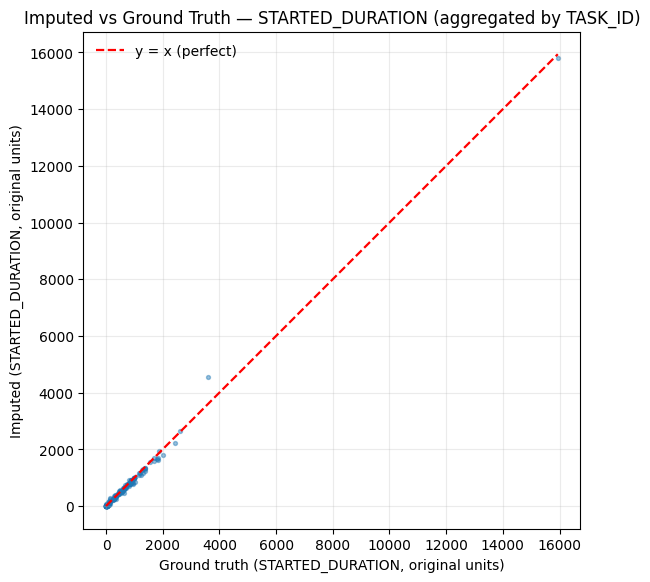

In [125]:
plt.figure(figsize=(6, 6))
plt.scatter(gt, imp, s=8, alpha=0.45, color="tab:blue")

lo = float(min(imp.min(), gt.min()))
hi = float(max(imp.max(), gt.max()))
plt.plot([lo, hi], [lo, hi], linestyle="--", color="red", linewidth=1.6, label="y = x (perfect)")

plt.xlabel(f"Ground truth ({target_feature}, original units)")
plt.ylabel(f"Imputed ({target_feature}, original units)")
plt.title(f"Imputed vs Ground Truth — {target_feature} (aggregated by TASK_ID)")
plt.gca().set_aspect("equal", "box")
plt.grid(True, alpha=0.25)
plt.legend(frameon=False, loc="best")
plt.tight_layout()
plt.show()
